<a href="https://colab.research.google.com/github/BenCheung1/Pytorch_Sandbox/blob/main/Pyt_IrisNN_EvalTestDataSet_Pt4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import torch
## Tensor basics: https://docs.pytorch.org/docs/2.13/tensors.html
## Iris Database https://archive.ics.uci.edu/dataset/53/iris
## Output: Iris Setosa, Iris Versicolour, Iris Virginica
## Input Features: Sepal length, width, Petal Len/Wid
## Torch Neural Net library & Functional NN Library
import torch.nn as nn
import torch.nn.functional as F

## Create a Model Class that inherits the nn.Module
class IrisModel (nn.Module):
    ## Input Layer (4 features of flow)
    ## --> Hidden Layer1 (number of neurons)
    ## --> H2(n)
    ## --> Output (3 classes of iris flowers)
    def __init__(self, in_features=4, hdnlyr1=8, hdnlyr2 =9, out_features =3):
       super().__init__() #Instantiate nn.Module
       ## Fully Connected Hidden Neural Layer "fc"
       self.fc1 = nn.Linear(in_features, hdnlyr1)
       self.fc2 = nn.Linear(hdnlyr1, hdnlyr2)
       self.out = nn.Linear(hdnlyr2, out_features)

    def forward(self, x):
       ## Rectified Linear Unit (Relu)
       x = F.relu(self.fc1(x))
       x = F.relu(self.fc2(x))
       x = self.out(x)
       return x

## Random a manual Seed for randomization
torch.manual_seed (87)
## create an instance of the model
model = IrisModel ()
import pandas as pd
import matplotlib.pyplot as Plt
%matplotlib inline
url = 'https://gist.githubusercontent.com/Thanatoz-1/9e7fdfb8189f0cdf5d73a494e4a6392a/raw/aaecbd14aeaa468cd749528f291aa8a30c2ea09e/iris_dataset.csv'
mydataframe = pd.read_csv(url)
mydataframe
## Change the last column from (output) strings to numbers
mydataframe['target'] = mydataframe['target'].replace('Iris-setosa',0.0)
mydataframe['target'] = mydataframe['target'].replace('Iris-versicolor',1.0)
mydataframe['target'] = mydataframe['target'].replace('Iris-virginica',2.0)
mydataframe['target'] = mydataframe['target'].infer_objects(copy=False)
# Train, Test, Split Set
# Set X = features (so drop the target column); and y = outcomes
# convention uppercase X, lowercase y
X = mydataframe.drop('target', axis=1)
y = mydataframe['target']
# Convert these to numpy Arrays
X = X.values
y = y.values

# Import Train, Test & Split from Sidekit Learn
from sklearn.model_selection import train_test_split
# Train Test Split (use 80% as "main" data, 20% as test)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state =87)

# Convert X features to float tensor
X_train= torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# Convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# Set the Criterion of model to measure the error, how far the predictions are from the data.
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer
# learning rate (lr) = (if error doesn't go down after iteractions epochs lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# the lower the learning rate the longer the training time

/tmp/ipykernel_2695/4092940050.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mydataframe['target'] = mydataframe['target'].replace('Iris-virginica',2.0)


In [38]:
# Train the Model
# Number of Epochs (one run through)
epoch = 100
# Keep track of errors, losses, python list
losses = []
for i in range(epoch):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) #get predicted results
  # Measure the loss/error, will be high at first
  loss = criterion(y_pred, y_train) #predicted value vs y_train value
  # Keep track of our losses
  losses.append(loss.detach().numpy())
  # Print every 10 epochs
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')
  # Do some back propagation:
  # take the error rate of forward propagation feed it back
  # through the network to fine tune the weights.
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 and loss: 1.0938360691070557
Epoch: 10 and loss: 0.8970173001289368
Epoch: 20 and loss: 0.6317557096481323
Epoch: 30 and loss: 0.45060017704963684
Epoch: 40 and loss: 0.3333239257335663
Epoch: 50 and loss: 0.2271062582731247
Epoch: 60 and loss: 0.15050937235355377
Epoch: 70 and loss: 0.10536763817071915
Epoch: 80 and loss: 0.07989642024040222
Epoch: 90 and loss: 0.06568585336208344


Text(0.5, 0, 'Epoch')

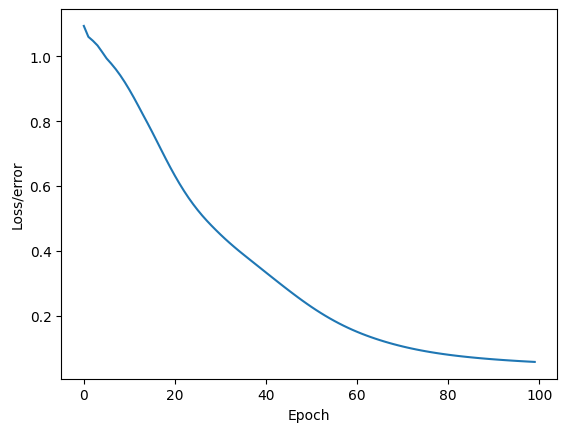

In [39]:
# Plot it out
Plt.plot(range(epoch), losses)
Plt.ylabel("Loss/error")
Plt.xlabel("Epoch")

In [40]:
# Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():  # turn off back propagation
  y_eval = model.forward(X_test) # X_test are features from our test set,
  # y_eval will be predictions
  loss = criterion (y_eval, y_test) #find the loss/error
correct = 0
with torch.no_grad():
  for i, data in enumerate (X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      rslt = "Setosa"
    elif y_test[i] == 1:
      rslt = 'Versicolor'
    else:
      rslt = 'Virginica'
    # Will tell us what type of iris the NN thinks it is
    print (f'{i+1}.) {str(y_val)} \t {rslt} \t {y_val.argmax().item()}')
    # the Highest number in the Tensor is what the NN thinks it is.
    # e.g. w/ 1. tensor 13.3, 7.22, -15.97 it is a type=0
    # Correct or Not
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print (f'We got {correct} correct')

1.) tensor([ 10.6507,   5.5240, -12.6803]) 	 Setosa 	 0
2.) tensor([-9.4010,  4.3234,  9.0612]) 	 Virginica 	 2
3.) tensor([-8.2383,  3.9295,  7.9224]) 	 Virginica 	 2
4.) tensor([-11.7495,   4.1138,  11.7168]) 	 Virginica 	 2
5.) tensor([-10.7002,   3.4919,  10.7721]) 	 Virginica 	 2
6.) tensor([-0.8639,  5.6000, -0.7529]) 	 Versicolor 	 1
7.) tensor([  9.6136,   5.0413, -11.4473]) 	 Setosa 	 0
8.) tensor([-2.9012,  4.7628,  1.7748]) 	 Versicolor 	 1
9.) tensor([-3.1100,  4.6388,  2.0568]) 	 Versicolor 	 1
10.) tensor([-2.7743,  4.9034,  1.5956]) 	 Versicolor 	 1
11.) tensor([ 11.6466,   6.0976, -13.8724]) 	 Setosa 	 0
12.) tensor([ 10.9956,   5.5948, -13.0836]) 	 Setosa 	 0
13.) tensor([  9.8824,   5.3652, -11.7818]) 	 Setosa 	 0
14.) tensor([-6.5188,  4.0715,  6.0053]) 	 Versicolor 	 2
15.) tensor([ 11.8235,   5.9554, -14.0659]) 	 Setosa 	 0
16.) tensor([ 10.0801,   5.2719, -12.0029]) 	 Setosa 	 0
17.) tensor([ 11.7025,   5.9125, -13.9230]) 	 Setosa 	 0
18.) tensor([ 0.3762,  4.9349

In [51]:
# Give a New Data Point (New Input) to the Neural Network
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])
with torch.no_grad():
  print(model(new_iris))
# output tensor 12 is highest # ... so result = Setosa.
IrisModel.eval

tensor([ 10.2336,   5.2605, -12.1792])


<function torch.nn.modules.module.Module.eval(self) -> Self>

In [42]:
new_flwrin = torch.tensor ([5.9,3.0,5.1,1.8])
with torch.no_grad():
  print(model(new_flwrin))
# output tensor 7.64 is highest # ... so result = virginica

tensor([-6.8838,  3.9618,  6.4411])


In [44]:
# Save the NN Model
torch.save (model.state_dict(), 'my_IrisNN_model.pt')
# Saves the weights, biases in trained model
# Load the Saved Model
new_model = IrisModel()
new_model.load_state_dict(torch.load('my_IrisNN_model.pt'))

<All keys matched successfully>

In [49]:
# Make sure it loaded correctly
new_model.eval()

IrisModel(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)